In [ ]:
!pip install cartopy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point, Polygon

In [ ]:
t_inicial = 0
t_final = 60*60*30# [s]
t_paso = 60*10 #[s]
g = 9.81
r = 6371000 #[m]


def valor_n(theta_radian, phi_radian):
    lat_deg = 90.0 - np.degrees(theta_radian)
    lon_deg = np.degrees(phi_radian)
    lon_deg_envuelta = lon_deg % 360

    h = -interpolador_real.ev(lat_deg, lon_deg_envuelta)

    if h <= 0:
        return np.inf
    c = np.sqrt(g * h)

    return 1.0 / c

def valor_n_uniforme(theta_radian, phi_radian):
    lat_deg = 90.0 - np.degrees(theta_radian)
    lon_deg = np.degrees(phi_radian)
    lon_deg_envuelta = lon_deg % 360

    h = -interpolador_uniforme.ev(lat_deg, lon_deg_envuelta)
    #h = 5400

    if h <= 0:
        return np.inf
    c = np.sqrt(g * h)

    return 1.0 / c

# la funcion principal que queremos resolver, variable independiente (tiempo) y dependiente iniciales [theta, phi, zeta]

#Epicentro Ejemplo: 35°S, 76°W.
#phi (Longitud) = -76 + 360 para nuevo sistema 0-360
#theta (colatitud) = (90° - Latitud)

def funcion_ray_tracing(t, y_inicial):

  #variables dependientes
  theta, phi, zeta = y_inicial
  lat_deg = 90.0 - np.degrees(theta)

  #por si el rayo llega al polo
  if abs(lat_deg) > 85.0:
      return np.array([0, 0, 0])

  n = valor_n(theta, phi)

  #se agregan varias condicionales por seguridad cuando los valores dan infinito o cercano a 0, de lo contrario el rayo genera unas curvas muy irreales, por ejemplo un
  #un rayo que se genera en chile, llega a australia, da una vuelta de aprox 180° y llega a california. El return entrega [0,0,0] entonces el rayo se quedaría quieto antes que pase algo raro.
  #aún siguen pasando trayectorias algo extrañas, pero los resultados se parecen un poco más a los del artículo. Estos eventos peculiares suelen pasar en los extremos de la batimetria
  if np.isinf(n) or abs(np.sin(theta)) < 1e-6:
      return np.array([0, 0, 0])

  d_theta = np.radians(0.01)
  d_phi = np.radians(0.01)
  dn_dtheta = (valor_n(theta + d_theta, phi) - valor_n(theta - d_theta, phi)) / (2 * d_theta)
  dn_dphi = (valor_n(theta, phi + d_phi) - valor_n(theta, phi - d_phi)) / (2 * d_phi)

  dtheta_dt = (1 / (n * r)) * np.cos(zeta)
  dphi_dt = (1 / (n * r * np.sin(theta))) * np.sin(zeta)

  #mas condicionales, esta nos sirve en la costa, cuando el rayo pase de una profundidad negativa a una positiva, generando una tasa de cambio demasiado alta que numpy toma como infinito
  if not np.isfinite(dn_dtheta) or not np.isfinite(dn_dphi):
      return np.array([0, 0, 0])

  primer_termino = -(np.sin(zeta) / (n**2 * r)) * dn_dtheta
  segundo_termino = (np.cos(zeta) / (n**2 * r * np.sin(theta))) * dn_dphi
  tercer_termino = -(1 / (n * r)) * np.sin(zeta) * (1 / np.tan(theta))
  dzeta_dt = primer_termino + segundo_termino + tercer_termino

  return np.array([dtheta_dt, dphi_dt, dzeta_dt])

#funcion para la batimetria uniforme
def funcion_ray_tracing_uniforme(t, y_inicial):
    theta, phi, zeta = y_inicial

    n = valor_n_uniforme(theta, phi)

    if abs(90.0 - np.degrees(theta)) > 85.0 :
        return np.array([0, 0, 0])

    dn_dtheta = 0
    dn_dphi = 0

    dtheta_dt = (1 / (n * r)) * np.cos(zeta)
    dphi_dt = (1 / (n * r * np.sin(theta))) * np.sin(zeta)
    dzeta_dt = -(1 / (n * r)) * np.sin(zeta) * (1 / np.tan(theta))

    return np.array([dtheta_dt, dphi_dt, dzeta_dt])


# el metodo runge kuta4
def rk4(f, xi, yi, h):
  k1 = f(xi, yi)
  k2 = f(xi + 0.5*h, yi + 0.5*k1*h)
  k3 = f(xi + 0.5*h, yi + 0.5*k2*h)
  k4 = f(xi + h, yi + k3*h)
  return yi + (1/6)*(k1 + 2*k2 + 2*k3 + k4)*h

# El solver de la función usando rk4
def calcular_parametros(f, t, y, dt):
  t_lista = []
  y_lista = []
  while t <= t_final:
    t_lista.append(t)
    y_lista.append(y)
    y = rk4(f, t, y, dt)
    t += dt

  return np.array(t_lista), np.array(y_lista)

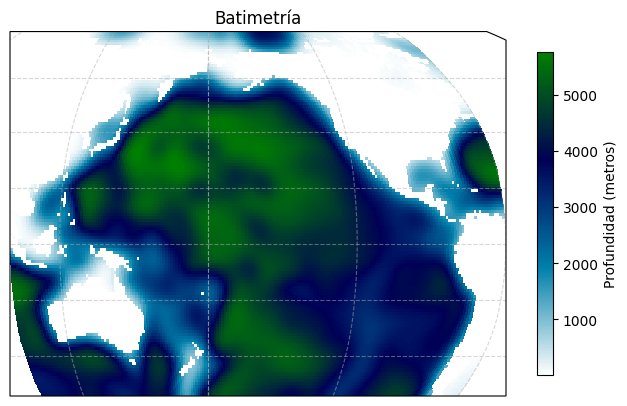

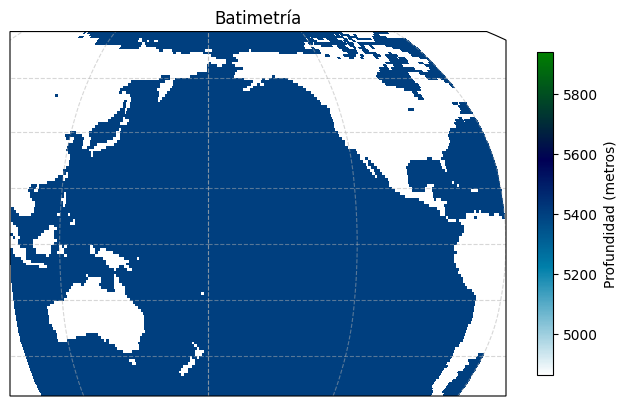

In [ ]:
#despues de muchas iteraciones viendo resultados, los valores se dejan en un promedio de 250 puntos de la batimetría original y un filtro gausiano muy potente de 3.2
#el problema de este promedio de 250 puntos es que muchas islas pequeñas desaparecen de la batimetria, por lo que los rayos pasarán por encima.
def batimetria(ruta_archivo, factor_promediado=250, sigma_gaussiano=3.2):

  ds = xr.open_dataset(ruta_archivo, chunks={'lat': 1000, 'lon': 1000})
  ds.coords['lon'] = (ds.coords['lon'] + 360) % 360
  ds = ds.sortby(ds.lon)

  dataset_suavizado = ds.coarsen(lon=factor_promediado, lat=factor_promediado, boundary='pad').mean()

  region_reducida = dataset_suavizado.sel(lon=slice(100, 300), lat=slice(-55, 80)).load()
  ds.close()

  elevacion_coarsened = region_reducida['elevation'].values
  lats = region_reducida['lat'].values
  lons = region_reducida['lon'].values

  mascara_tierra = elevacion_coarsened >= 0

  elevacion_oceano = np.copy(elevacion_coarsened)
  elevacion_oceano[mascara_tierra] = np.nan
  elevacion_rellena = np.copy(elevacion_oceano)
  elevacion_rellena[np.isnan(elevacion_oceano)] = 0

  elevacion_filtrada = gaussian_filter(elevacion_rellena, sigma=sigma_gaussiano)

  elevacion_final_real = np.where(mascara_tierra, elevacion_coarsened, elevacion_filtrada)

  if lats[0] > lats[-1]:
    lats = lats[::-1]
    elevacion_final_real = np.flipud(elevacion_final_real)

  elevacion_uniforme = np.where(mascara_tierra, elevacion_coarsened, -5400.0)

  interpolador_real = RectBivariateSpline(lats, lons, elevacion_final_real, kx=3, ky=3)
  interpolador_uniforme = RectBivariateSpline(lats, lons, elevacion_uniforme, kx=1, ky=1)

  # 3. Devolver todos los resultados en una sola tupla
  return interpolador_real, lats, lons, elevacion_final_real, interpolador_uniforme, elevacion_uniforme


interpolador_real, lats, lons, elevacion_final_real, interpolador_uniforme, elevacion_uniforme= batimetria('/content/drive/MyDrive/GEBCO_2025_sub_ice.nc')


profundidad_real = -elevacion_final_real
profundidad_real[profundidad_real < 0] = np.nan

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=180))


mapa = ax.pcolormesh(lons, lats, profundidad_real, cmap='ocean_r', transform=ccrs.PlateCarree())
fig.colorbar(mapa, ax=ax, label='Profundidad (metros)', shrink=0.7)

ax.gridlines(linestyle='--', alpha=0.5)
ax.set_title('Batimetría')
plt.show()
###
profundidad_uniforme = -elevacion_uniforme
profundidad_uniforme[profundidad_uniforme < 0] = np.nan

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=180))


mapa = ax.pcolormesh(lons, lats, profundidad_uniforme, cmap='ocean_r', transform=ccrs.PlateCarree())
fig.colorbar(mapa, ax=ax, label='Profundidad (metros)', shrink=0.7)

ax.gridlines(linestyle='--', alpha=0.5)
ax.set_title('Batimetría')
plt.show()

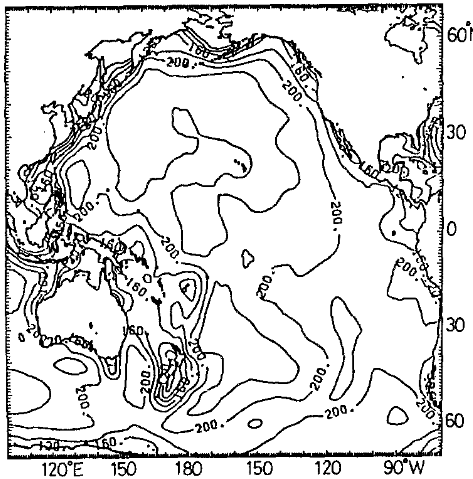

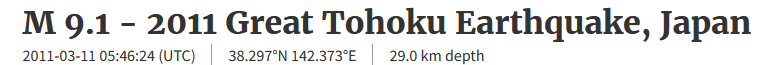

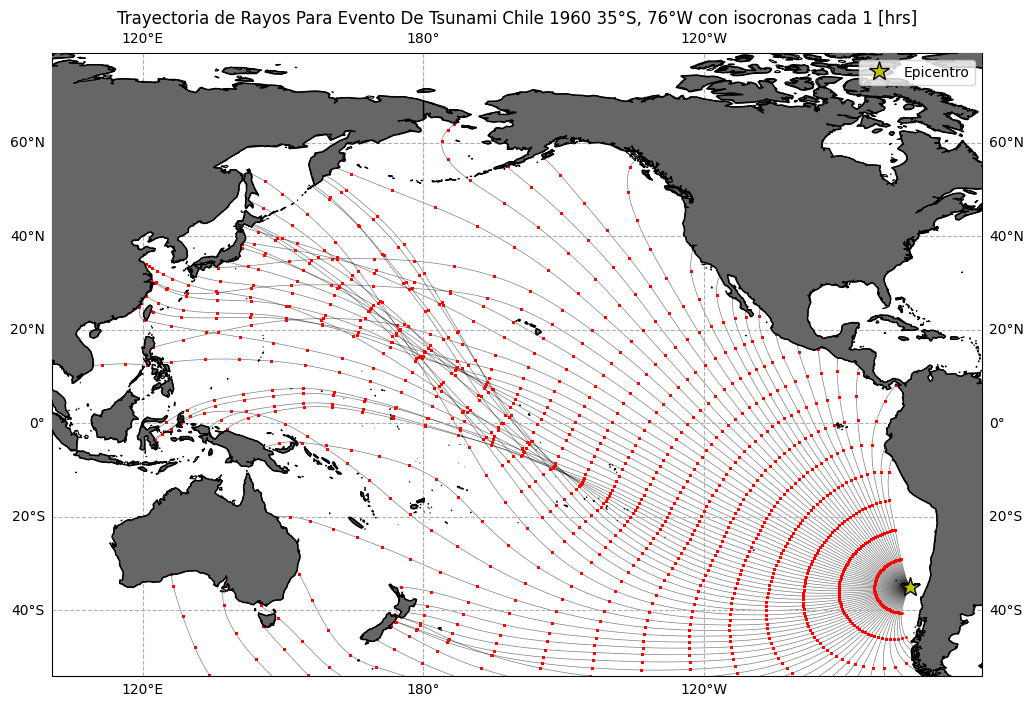

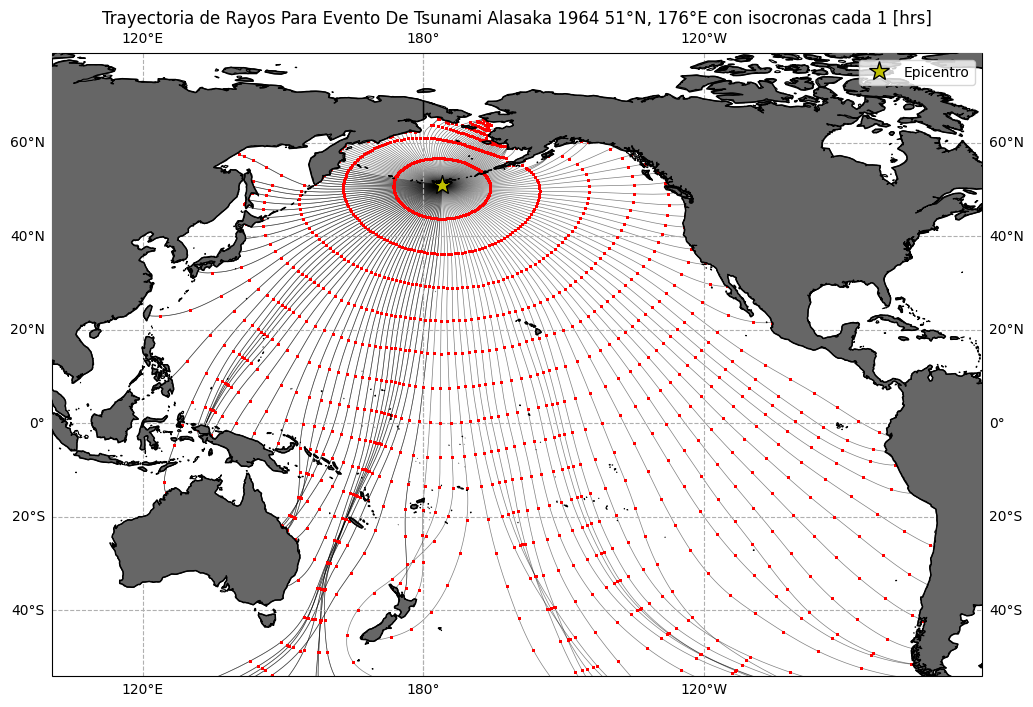

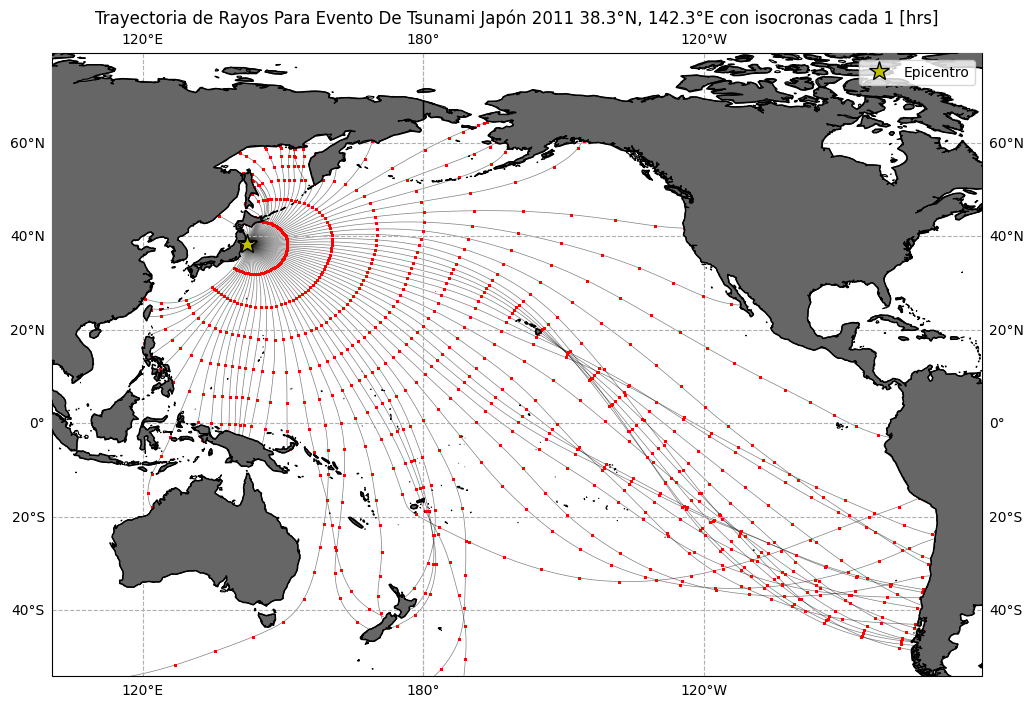

In [ ]:
def funcion_trayectorias(f, evento, azimuths_deg):
  trayectorias = []
  #usamos nuestro solver para un array de azimuts
  for az in azimuths_deg:
    valor_inicial = np.array([ np.radians(90 - evento[0]), np.radians(evento[1] % 360), np.radians(az)])
    t_array, y_array = calcular_parametros(f, t_inicial, valor_inicial, t_paso)
    trayectorias.append(y_array)

  return t_array, np.array(trayectorias)

def graficar_resultados(t_array, trayectorias_array, evento, nombre_evento):

  fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
  tiempo_total_simulacion = t_array[-1]
  intervalo_horas = 1
  tiempos_isocronas = np.arange(3600, tiempo_total_simulacion + 1, 3600 * intervalo_horas)

  for t_isocrona in tiempos_isocronas:
    puntos_lon_iso = []
    puntos_lat_iso = []

    for y_array in trayectorias_array:
      lon_rad_interp = np.interp(t_isocrona, t_array, y_array[:, 1])
      colat_rad_interp = np.interp(t_isocrona, t_array, y_array[:, 0])
      puntos_lon_iso.append(np.degrees(lon_rad_interp))
      puntos_lat_iso.append(90.0 - np.degrees(colat_rad_interp))
      ax.scatter(puntos_lon_iso, puntos_lat_iso, color='red', s=1, transform=ccrs.Geodetic(), zorder=3)

  for y_array in trayectorias_array:
    latitudes_deg = 90.0 - np.degrees(y_array[:, 0])
    longitudes_deg = np.degrees(y_array[:, 1])
    ax.plot(longitudes_deg, latitudes_deg, color='black', linewidth=0.5, alpha=0.5, zorder=2, transform=ccrs.Geodetic())

  ax.add_feature(cfeature.LAND, zorder=4, edgecolor='black', facecolor='#666666')
  ax.coastlines(resolution='50m', zorder=4, linewidth=0.8)
  ax.plot(evento[1], evento[0], 'y*', markersize=15, markeredgecolor='black', label='Epicentro', zorder=5, transform=ccrs.PlateCarree())
  ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())
  ax.gridlines(draw_labels=True, linestyle='--')
  ax.legend(loc="upper right")

  ax.set_title(f"Trayectoria de Rayos Para Evento De Tsunami {nombre_evento} con isocronas cada 1 [hrs]")
  plt.show()


#Eventos
evento_chile_1960 = [-35, -76] # lat, long
evento_alaska_1964 = [51, -176] #lat, long
evento_japon_2011 = [38.3, 142.3] #lat, long #los resultados serán iguales que el de 1964


#Array de azimuths, Se elije un set que de resultados más parecidos a los del investigador
azimuths_evento_chile_1960 = np.arange(-160, -20, 2)
azimuths_evento_alaska__1964 = np.arange(-100, 360, 2)
azimuths_evento_japon__2011 = np.arange(-60, 280, 2)

#procesamiento Chile 1960
tiempo_chile, trayectorias_chile = funcion_trayectorias(funcion_ray_tracing, evento_chile_1960, azimuths_evento_chile_1960)
graficar_resultados(tiempo_chile, trayectorias_chile, evento_chile_1960, "Chile 1960 35°S, 76°W")

#procesamiento Japon 1964
tiempo_alaska_1964, trayectorias_alaska_1964 = funcion_trayectorias(funcion_ray_tracing, evento_alaska_1964, azimuths_evento_alaska__1964)
graficar_resultados(tiempo_alaska_1964, trayectorias_alaska_1964, evento_alaska_1964, "Alasaka 1964 51°N, 176°E")

#procesamiento Japon 2011
tiempo_japon__2011, trayectorias_japon__2011 = funcion_trayectorias(funcion_ray_tracing, evento_japon_2011, azimuths_evento_japon__2011)
graficar_resultados(tiempo_japon__2011, trayectorias_japon__2011, evento_japon_2011, "Japón 2011 38.3°N, 142.3°E")

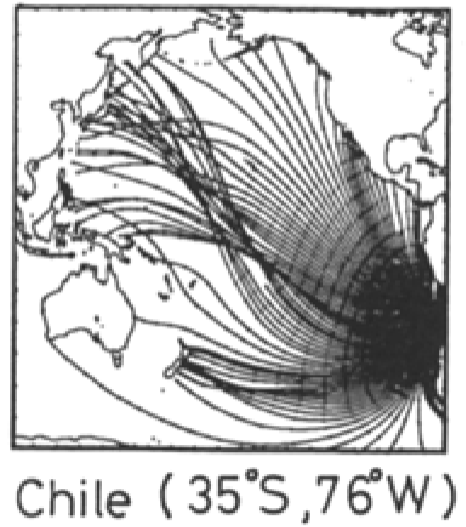
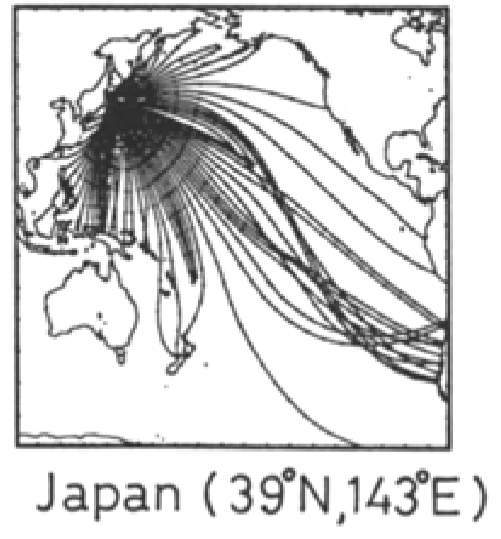
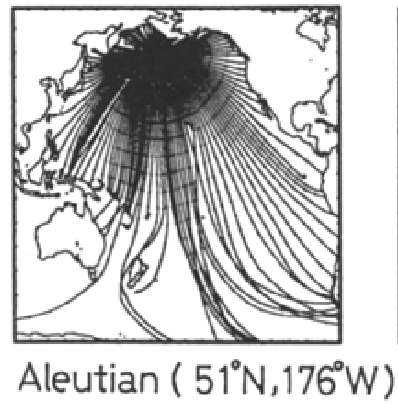

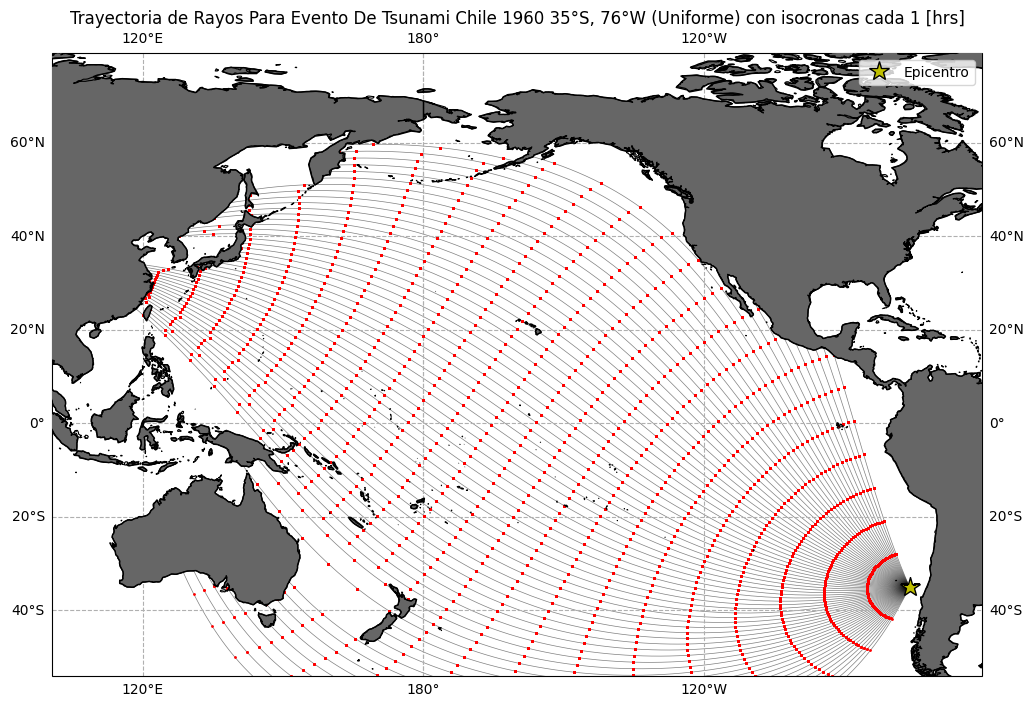

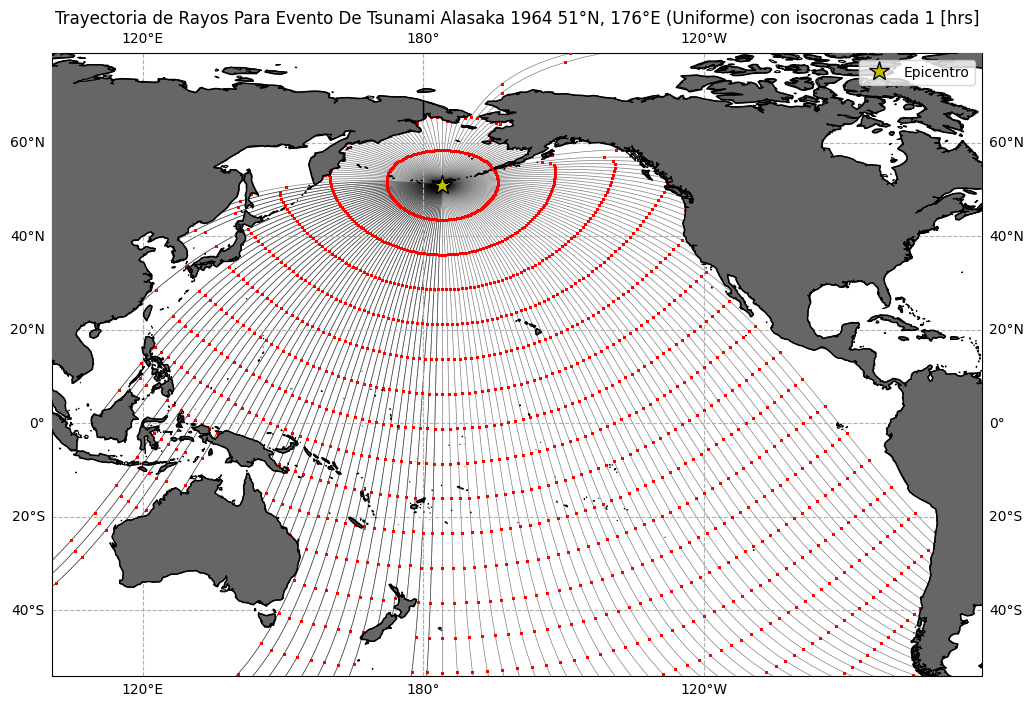

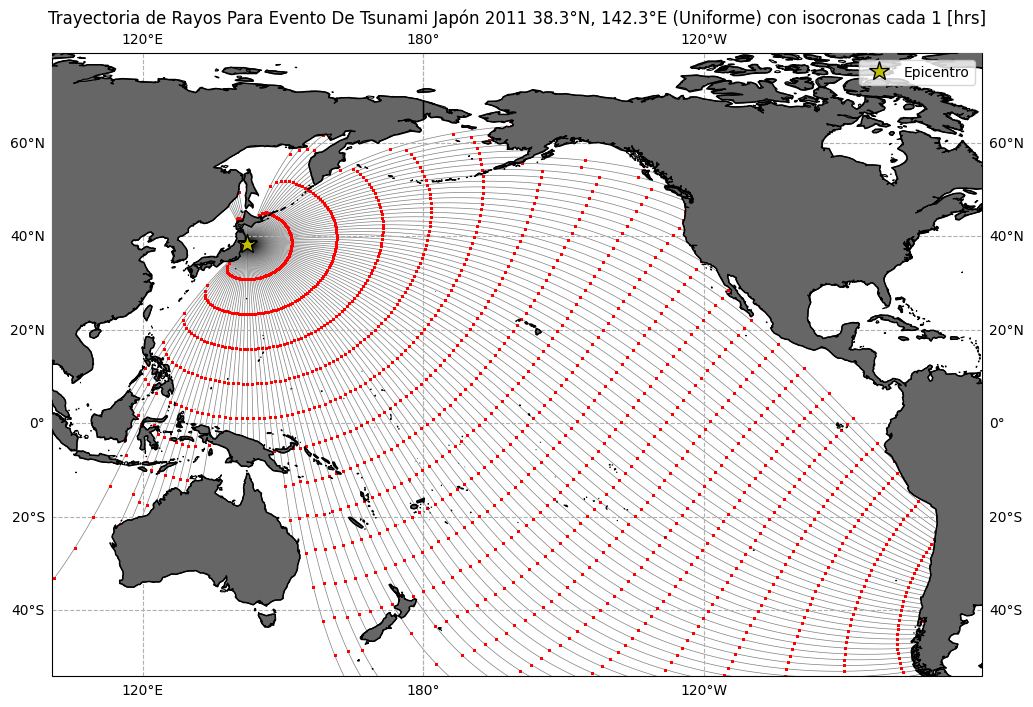

In [ ]:
#procesamiento con batimetria uniforme

#procesamiento Chile 1960
tiempo_chile_uniforme, trayectorias_chile_uniforme = funcion_trayectorias(funcion_ray_tracing_uniforme, evento_chile_1960, azimuths_evento_chile_1960)
graficar_resultados(tiempo_chile_uniforme, trayectorias_chile_uniforme, evento_chile_1960, "Chile 1960 35°S, 76°W (Uniforme)")

#procesamiento alaska 1964
tiempo_alaska_1964_uniforme, trayectorias_alaska_1964_uniforme = funcion_trayectorias(funcion_ray_tracing_uniforme, evento_alaska_1964, azimuths_evento_alaska__1964)
graficar_resultados(tiempo_alaska_1964_uniforme, trayectorias_alaska_1964_uniforme, evento_alaska_1964, "Alasaka 1964 51°N, 176°E (Uniforme)")

#procesamiento Japon 2011
tiempo_japon__2011_uniforme, trayectorias_japon__2011_uniforme = funcion_trayectorias(funcion_ray_tracing_uniforme, evento_japon_2011, azimuths_evento_japon__2011)
graficar_resultados(tiempo_japon__2011_uniforme, trayectorias_japon__2011_uniforme, evento_japon_2011, "Japón 2011 38.3°N, 142.3°E (Uniforme)")

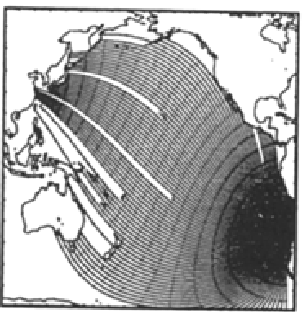
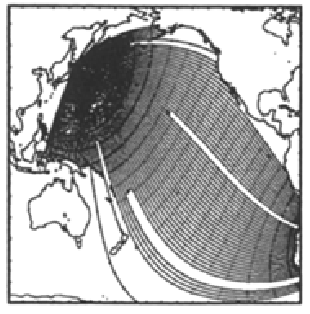
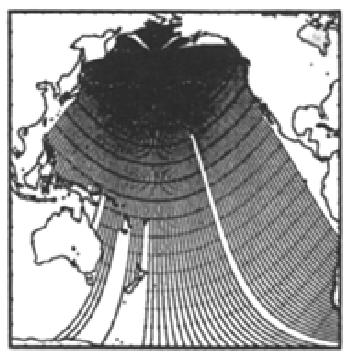

In [ ]:
poligono_japon = [(128, 30), (145, 30), (148, 46),(138, 46)]
poligono_chile = [(284, -50), (294, -50), (289, -18), (279, -18)]

def contar_impactos_en_zona(lista_de_trayectorias, zona_poligono):
  poligono = Polygon(zona_poligono)

  impactos_en_zona = []

  for trayectoria in lista_de_trayectorias:
    ultimo_punto_rad = trayectoria[-1]
    lon_deg = np.degrees(ultimo_punto_rad[1])
    lat_deg = 90.0 - np.degrees(ultimo_punto_rad[0])
    punto_impacto = Point(lon_deg, lat_deg)

    if poligono.contains(punto_impacto):
        impactos_en_zona.append((lon_deg, lat_deg))

  return impactos_en_zona, len(impactos_en_zona)

#ya que las islas pequeñas se borraron por lo la poca resolución, solo se compara el los impactos en las costas de japon y chile.

#Impactos en Japon desde Alaska y Chile
impactos_japon_chile_real = contar_impactos_en_zona(trayectorias_chile, poligono_japon)[1]
impactos_japon_chile_uniforme = contar_impactos_en_zona(trayectorias_chile_uniforme, poligono_japon)[1]

impactos_japon_alaska_real = contar_impactos_en_zona(trayectorias_alaska_1964, poligono_japon)[1]
impactos_japon_alaska_uniforme = contar_impactos_en_zona(trayectorias_alaska_1964_uniforme, poligono_japon)[1]

print(f"Impactos desde Chile a Japón en batimetria real:{impactos_japon_chile_real}. En batimetria uniforme:{impactos_japon_chile_uniforme}")
print(f"Impactos desde Alaska a Japón en batimetria real:{impactos_japon_chile_real}. En batimetria uniforme:{impactos_japon_chile_uniforme}")

#Impactos en Chile desde Alaska y Japón
impactos_chile_japon_real = contar_impactos_en_zona(trayectorias_japon__2011, poligono_chile)[1]
impactos_chile_japon_uniforme = contar_impactos_en_zona(trayectorias_japon__2011_uniforme, poligono_chile)[1]

impactos_chile_alaska_real = contar_impactos_en_zona(trayectorias_alaska_1964, poligono_chile)[1]
impactos_chile_alaska_uniforme = contar_impactos_en_zona(trayectorias_alaska_1964_uniforme, poligono_chile)[1]

print(f"Impactos desde Japón a Chile en batimetria real:{impactos_chile_japon_real}. En batimetria uniforme:{impactos_chile_japon_uniforme}")
print(f"Impactos desde Alaska a Chile en batimetria real:{impactos_chile_alaska_real}. En batimetria uniforme:{impactos_chile_alaska_uniforme}")

#calculo de p_rays

p_ray_japon_chile = impactos_japon_chile_real/impactos_japon_chile_uniforme
p_ray_alaska_chile = impactos_chile_alaska_real/impactos_chile_alaska_uniforme
#le asignamos el mismo numero a ambos eventos
p_ray_chile_japon = impactos_chile_japon_real/impactos_chile_japon_uniforme
p_ray_alaska_japon = impactos_japon_alaska_real/impactos_japon_alaska_uniforme


print(f"p_ray en Japon por evento en Chile = {p_ray_japon_chile}")
print(f"p_ray en Japon por evento en Alaska = {p_ray_alaska_japon}")
print(f"p_ray en Chile por evento en Japon = {p_ray_chile_japon}")
print(f"p_ray en Chile por evento en Alaska = {p_ray_alaska_chile}")

Impactos desde Chile a Japón en batimetria real:10. En batimetria uniforme:11
Impactos desde Alaska a Japón en batimetria real:10. En batimetria uniforme:11
Impactos desde Japón a Chile en batimetria real:18. En batimetria uniforme:27
Impactos desde Alaska a Chile en batimetria real:4. En batimetria uniforme:14
p_ray en Japon por evento en Chile = 0.9090909090909091
p_ray en Japon por evento en Alaska = 1.0
p_ray en Chile por evento en Japon = 0.6666666666666666
p_ray en Chile por evento en Alaska = 0.2857142857142857


Según el articulo, el único evento donde la diferencia entre la batimetría uniforme y real se considera significativa es en las costas chilenas desde Alaska, todas las demás costas (ignorando la de alaska, ya que no se pudo analizar) son no significantes.

En nuestra modelación encontramos que esto se cumplío para todos los eventos simulados ya que el articulo menciona que para considerarse una diferencia no significativa, el valor p_ray debe estar entre 0.6 y 1.6, mientras que menor a 0.6 se considera que se subestimó la cantidad de rayos. Todo lo anterior se cumplió para los 4 casos. Esto se debe al tipo de filtrado y suavizado que se utilizó en nuestra modelación generó patrones muy similares a la batimetría del artículo. Esto nos señala que habriamos obtenido los mismo cálculos que el investigador en la simulación de las islas de alaska de haberse podido modelar.

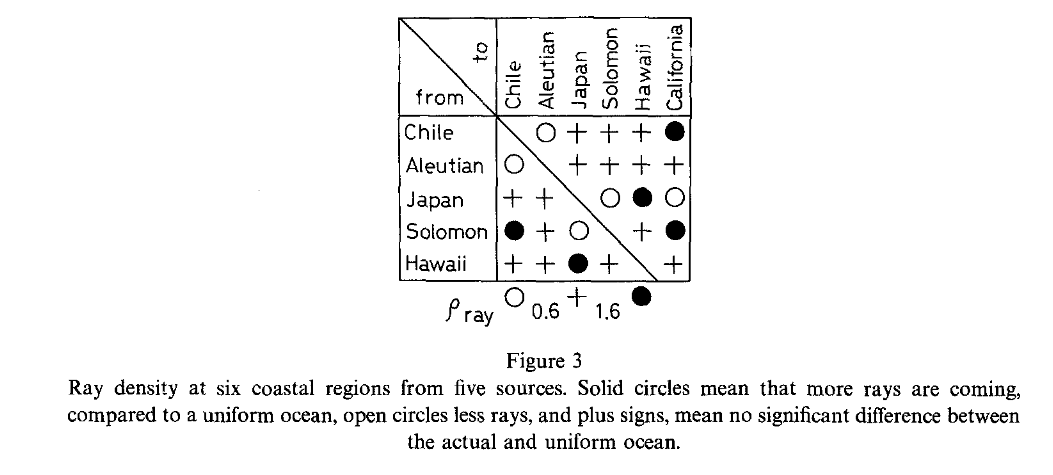

La razón por la que teóricamente la cantidad de rayos debe ser muy similar, en las zona con p_ray cercano a 1, durante en el impacto se debe a que la topografía del oceano pacífico está compuesta de tal forma que la refracción producto a los cambios de profundidad compensa el hecho de que esta ya no es uniforme. De haber una topografía diferente esto no sucedería, ya que el resultado de refracción sería diferente, por lo que se podría decir que de casualidad tanto la uniforme como real coinciden en el numero de impactos. Esto fue lo que no paso en la costa de Chile producto del evento en Alaska, pero si en las demás costas.

Esto significa que el p_ray, que es un termino que cuantifica la concentración neta de energía, teóricamente al ser 1, la altura de ola que impacta la costa debería ser muy similar tanto para la batimetria real y uniforme. Esto se debe a que impactan la misma cantidad de rayos, por lo tanto los efectos de refracción no son dominantes y la ola solo disminuira por efectos de shoaling y la distancia que recorre el rayo (que debería variar por muy poco en relación a la longitud total).
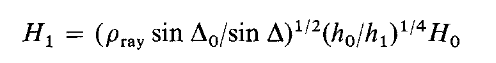


Se puede obtener la altura de cada rayo con la formula anterior, sin embargo, los datos del investigador son para el tsunami del mar de japon de 1983. Por lo tanto nos faltarian varios datos como delta_0 y H0. Además no tendriamos datos con que comparar la ola que entrega la formula, a diferencia de todos los calculos anteriores que sí se pudieron verificar con la información del investigador. Sin embargo, cualitativamentne podemos decir que ignorando el shoaling y la distancia del rayo, a mayor concencetración de rayos (mayor p_ray) se concentrará más energía y por lo tanto la ola tendrá mas altura. Y viceversa para menos rayos, habrá menos energía y altura.